# Classification using Logistic Regression

 ## Problem Statement
- Predict if the customer will leave the bank
- `Exited` will be a dependent variable 

### Import required packages

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv('./Churn_Modelling.csv')

### Exploratry data analysis

In [31]:
# General information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [32]:
# Get stastical information
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Data Cleansing

In [33]:
# Since the RowNumber, CustomerId and Surname are not useful for predicting the Exited value, drop them
df.drop(['RowNumber','CustomerId','Surname'], axis = 1, inplace = True)

In [34]:
from sklearn.preprocessing import LabelEncoder

# Convert the Geography to numeric data type
geography_encoder = LabelEncoder()
geography_encoder.fit(df['Geography'])
df['Geography'] = geography_encoder.transform(df['Geography'])

# Convert the Gender to numeric data type
gender_encoder = LabelEncoder()
gender_encoder.fit(df['Gender'])
df['Gender'] = gender_encoder.transform(df['Gender'])

In [35]:
# Verify all varibales are numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


In [36]:
# Check if there are any missing values
df.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [37]:
# Perform correlation analysis
df.corr()['Exited'].abs().sort_values()

HasCrCard          0.007138
EstimatedSalary    0.012097
Tenure             0.014001
CreditScore        0.027094
Geography          0.035943
NumOfProducts      0.047820
Gender             0.106512
Balance            0.118533
IsActiveMember     0.156128
Age                0.285323
Exited             1.000000
Name: Exited, dtype: float64

### Data preprocessing

In [38]:
# SPlit the data into x and y
x = df.drop('Exited', axis = 1)
y = df['Exited']

In [39]:
# Split data into train and test
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size= 0.8, random_state=42)

### Train the model

In [40]:
from sklearn.linear_model import LogisticRegressionCV

# Create a model
model = LogisticRegressionCV(max_iter=1000)

# Train the model
model.fit(x_train, y_train)

,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,1000
,class_weight,None
,n_jobs,None


In [41]:
y_pred = model.predict(x_test)

### Model evaluation

In [42]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[1559,   48],
       [ 321,   72]])

In [43]:
# Accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8155

In [44]:
# Precision
from sklearn.metrics import precision_score
precision_score(y_test, y_pred)

0.6

In [45]:
# Recall
from sklearn.metrics import recall_score
recall_score(y_test, y_pred)

0.183206106870229

In [46]:
# F-1 Score 
from sklearn.metrics import f1_score
f1_score(y_test, y_pred)

0.2807017543859649

In [47]:
# ROC - AUC value
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

0.5766683925763716

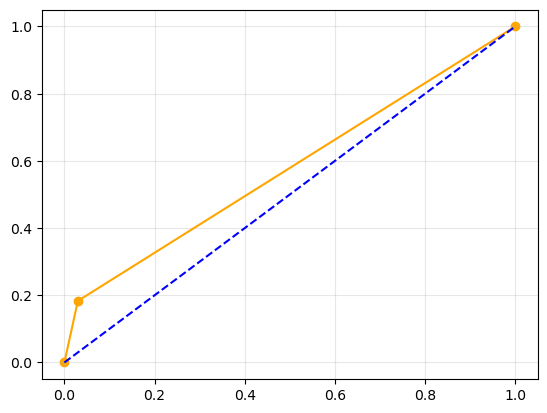

In [59]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, y_pred)
plt.scatter(fpr, tpr, color = "orange")
plt.plot(fpr, tpr, color = "orange")
plt.plot([0, 1], [0, 1], "b--")
plt.grid(alpha = 0.3)

### Result visualization

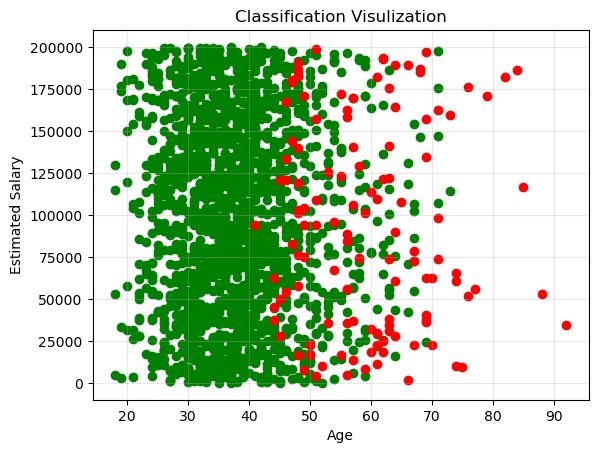

In [53]:
plt.scatter(x_test['Age'][y_pred == 0], x_test['EstimatedSalary'][y_pred == 0], color = "green")
plt.scatter(x_test['Age'][y_pred == 1], x_test['EstimatedSalary'][y_pred == 1], color = "red")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Classification Visulization")
plt.grid(alpha = 0.3)